# 06 — Baseline Model: Predict Price Movement

## Goal
Predict whether the mid-price moves at the next time step (`mid_price_moves`).

# prelim
- 1 model to do both then split

## Setup
Binary classification:
- 1 = move
- 0 = no move

## Plan
- Time-based train/test split  
- Train logistic regression baseline  
- Evaluate performance

In [34]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [35]:
target = "mid_price_moves"

In [36]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

final_dataset[target].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

make sure time ordered

In [37]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)
len(final_dataset)

43999

In [38]:
final_dataset = final_dataset.dropna().reset_index(drop=True)
len(final_dataset)

43999

# transform some vars

In [39]:
final_dataset["log_avg_trade_size"] = np.log(final_dataset["avg_trade_size"] + 1e-9)

# feature list

In [40]:
lob_features = [
    "lob_bids_price_1",
    "lob_bids_price_2",
    "lob_bids_price_3",
    "lob_bids_price_4",
    "lob_bids_price_5",
    "lob_bids_price_6",
    "lob_bids_price_7",
    "lob_bids_price_8",
    "lob_bids_price_9",
    "lob_bids_price_10",
    "lob_bids_volume_1",
    "lob_bids_volume_2",
    "lob_bids_volume_3",
    "lob_bids_volume_4",
    "lob_bids_volume_5",
    "lob_bids_volume_6",
    "lob_bids_volume_7",
    "lob_bids_volume_8",
    "lob_bids_volume_9",
    "lob_bids_volume_10",
    "lob_asks_price_1",
    "lob_asks_price_2",
    "lob_asks_price_3",
    "lob_asks_price_4",
    "lob_asks_price_5",
    "lob_asks_price_6",
    "lob_asks_price_7",
    "lob_asks_price_8",
    "lob_asks_price_9",
    "lob_asks_price_10",
    "lob_asks_volume_1",
    "lob_asks_volume_2",
    "lob_asks_volume_3",
    "lob_asks_volume_4",
    "lob_asks_volume_5",
    "lob_asks_volume_6",
    "lob_asks_volume_7",
    "lob_asks_volume_8",
    "lob_asks_volume_9",
    "lob_asks_volume_10",
    "log_depth_ratio_2",
    "log_depth_ratio_3",
    "log_depth_ratio_4",
    "log_depth_ratio_5",
    "log_depth_ratio_6",
    "log_depth_ratio_7",
    "log_depth_ratio_8",
    "log_depth_ratio_9",
    "log_depth_ratio_10",
]

spread_features = ["rel_spread", "spread"]
imbalance_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_1",
    "imbalance_depth_2",
    "imbalance_depth_3",
    "imbalance_depth_4",
    "imbalance_depth_5",
    "imbalance_depth_6",
    "imbalance_depth_7",
    "imbalance_depth_8",
    "imbalance_depth_9",
    "imbalance_depth_10",
]
liquidity_features = [
    "liquidity",
    "total_bid_volume_10",
    "total_ask_volume_10",
    "total_book_volume",
    "max_bid_ask_vol_ratio",
]
microprice_features = [
    "microprice",
    "microprice_change",
    "mid_minus_micro",
    "microprice_weighted_10",
]
return_features = [
    "return_1",
    "return_5",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "log_return_20",
    "mid_price_change_1",
    "mid_price_change_5",
    "mid_price_change_20",
]
momentum_features = [
    "momentum_5_log_return_1",
    "momentum_20_log_return_1",
]
volatility_features = [
    "vol_5",
    "vol_20",
    "realized_vol_5",
    "realized_vol_20",
]
trade_activity_features = [
    "trade_count",
        "buy_count",
            "sell_count",
]
trade_volume_features = [
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "max_over_average",
]
trade_flow_features = [
    "trade_volume_imbalance",
]
trade_dynamics_features = [
    "trade_volume_change",
    "trade_count_change",
]
lagged_trade_features = [
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",
]
feature_groups = {
    "lob_features": lob_features,
    "spread": spread_features,
    "imbalance": imbalance_features,
    "liquidity": liquidity_features,
    "microprice": microprice_features,
    "returns": return_features,
    "momentum": momentum_features,
    "volatility": volatility_features,
    "trade_activity": trade_activity_features,
    "trade_volume": trade_volume_features,
    "trade_flow": trade_flow_features,
    "trade_dynamics": trade_dynamics_features,
    "lagged_trade": lagged_trade_features,
}
all_features = (
    lob_features
    + spread_features
    + imbalance_features
    + liquidity_features
    + microprice_features
    + return_features
    + momentum_features
    + volatility_features
    + trade_activity_features
    + trade_volume_features
    + trade_flow_features
    + trade_dynamics_features
    + lagged_trade_features
)

In [41]:
features = [
    "imbalance_1",
    "imbalance_5",
    "log_depth_ratio_3",
    "log_depth_ratio_5",
    "mid_minus_micro",
    "microprice_change",
    "spread",
    "rel_spread",
    "vol_5",
    "vol_20",
    "trade_count",
    "buy_count",
    "sell_count",
    "trade_volume_change",
    "trade_count_change",
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "log_avg_trade_size",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "max_over_average",
    "log_depth_ratio_2",
    "log_depth_ratio_3",
    "log_depth_ratio_4",
    "log_depth_ratio_5",
    "log_depth_ratio_6",
    "log_depth_ratio_7",
    "log_depth_ratio_8",
    "log_depth_ratio_9",
    "log_depth_ratio_10",
    "imbalance_depth_1",
    "imbalance_depth_2",
    "imbalance_depth_3",
    "imbalance_depth_4",
    "imbalance_depth_5",
    "imbalance_depth_6",
    "imbalance_depth_7",
    "imbalance_depth_8",
    "imbalance_depth_9",
    "imbalance_depth_10",
    "liquidity",
    "total_bid_volume_10",
    "total_ask_volume_10",
    "total_book_volume",
    "max_bid_ask_vol_ratio",
    "trade_volume_imbalance",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",

]
features_clean = [
    "vol_20",
    "spread",
    "rel_spread",
    "trade_count",
    "avg_trade_size",
]

target = "mid_price_moves"

features = all_features

<Axes: >

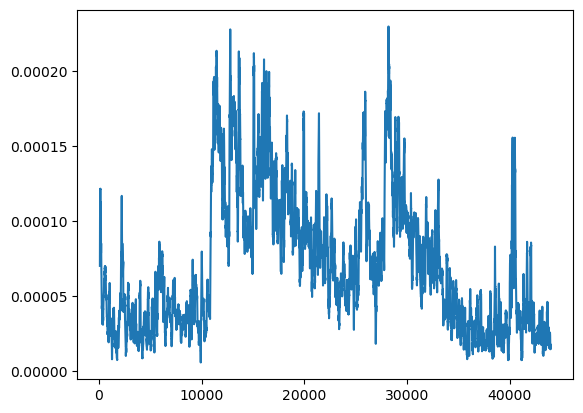

In [42]:
final_dataset["vol_5"].rolling(100).mean().plot()

Regime shifts as we move through time so need a way to account for this
- rolling folds?
- walk forward


# Splitting train/test
- using timeseriessplit to get performance even with regime shift

In [43]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=10, gap=50)

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
all_coefs = []
fold_aucs = []
oof_preds = np.zeros(len(final_dataset))

for train_idx, test_idx in tscv.split(final_dataset):

    X_train = final_dataset.iloc[train_idx][features]
    y_train = final_dataset.iloc[train_idx][target]

    X_test = final_dataset.iloc[test_idx][features]
    y_test = final_dataset.iloc[test_idx][target]   # <-- ADD THIS

    # SCALE
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # MODEL
    model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=1.0,                # inverse of lambda
        max_iter=1000
    )
    model.fit(X_train_scaled, y_train)
    all_coefs.append(model.coef_[0])

    preds = model.predict_proba(X_test_scaled)[:, 1]

    oof_preds[test_idx] = preds

    # AUC per fold
    auc = roc_auc_score(y_test, preds)   # <-- ADD THIS
    fold_aucs.append(auc)               # <-- ADD THIS

c:\Users\jayod\miniconda3\envs\microstructure-alpha-engine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jayod\miniconda3\envs\microstructure-alpha-engine\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\jayod\miniconda3\envs\microstructure-alpha-engine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instea

In [45]:
print("Fold AUCs:", fold_aucs)
print("Mean:", np.mean(fold_aucs))
print("Std:", np.std(fold_aucs))

# overall OOF AUC
print("OOF AUC:", roc_auc_score(final_dataset[target], oof_preds))

Fold AUCs: [0.7807996346294725, 0.8502567835232474, 0.6678800917090942, 0.6786025323239767, 0.6837281692895955, 0.705487757901509, 0.6730674784525581, 0.7108435371554386, 0.668390418563849, 0.7846867752478203]
Mean: 0.7203743178796561
Std: 0.05979376247469306
OOF AUC: 0.7567684722945346


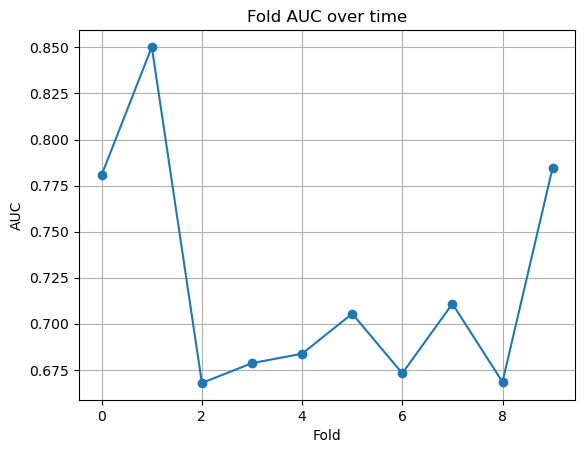

In [46]:
import matplotlib.pyplot as plt

plt.plot(fold_aucs, marker='o')
plt.title("Fold AUC over time")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.grid()

Text(0.5, 1.0, 'OOF Predictions vs Target (clean)')

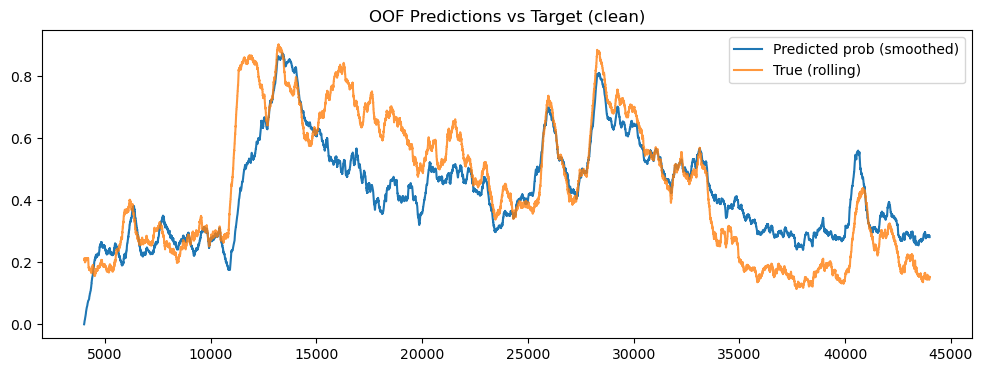

In [47]:
mask = oof_preds != 0  # remove non-predicted region

plt.figure(figsize=(12,4))
pred_smooth = pd.Series(oof_preds).rolling(500).mean()

plt.plot(pred_smooth[mask], label="Predicted prob (smoothed)")
# predictions
#plt.plot(oof_preds[mask], label="Predicted prob")

# smoothed target (much better)
target_smooth = final_dataset[target].rolling(500).mean()
plt.plot(target_smooth[mask], label="True (rolling)", alpha=0.8)

plt.legend()
plt.title("OOF Predictions vs Target (clean)")

Text(0.5, 1.0, 'Prediction distribution')

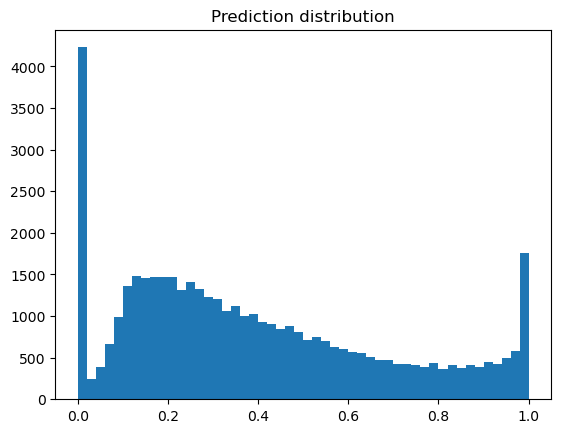

In [48]:
plt.hist(oof_preds, bins=50)
plt.title("Prediction distribution")

Text(0.5, 1.0, 'AUC over time chunks')

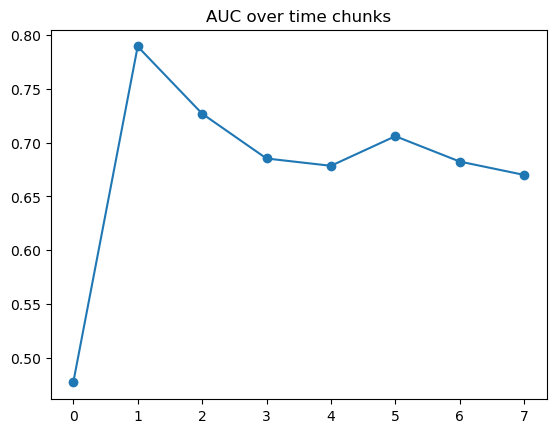

In [49]:
chunk_size = 5000
aucs = []

for i in range(0, len(oof_preds) - chunk_size, chunk_size):
    y_chunk = final_dataset[target].iloc[i:i+chunk_size]
    p_chunk = oof_preds[i:i+chunk_size]

    aucs.append(roc_auc_score(y_chunk, p_chunk))

plt.plot(aucs, marker='o')
plt.title("AUC over time chunks")

In [ ]:
import pandas as pd

avg_coefs = pd.Series(np.mean(all_coefs, axis=0), index=features)
avg_coefs = avg_coefs.sort_values(key=abs, ascending=False)
pd.set_option("display.max_rows", None)
print(avg_coefs)


realized_vol_20                 0.797945
avg_trade_size                 -0.712499
max_bid_ask_vol_ratio           0.622843
trade_count                     0.600427
sell_count                      0.471014
buy_count                       0.370277
realized_vol_5                  0.334658
trade_count_change              0.274977
std_trade_size                  0.258847
imbalance_10                   -0.190424
rel_spread                      0.187403
spread                          0.186519
imbalance_5                     0.160029
imbalance_depth_5              -0.158170
vol_20                         -0.154236
vol_5                          -0.152026
log_depth_ratio_5               0.149074
min_trade_size                  0.140262
lob_bids_volume_3               0.124178
buy_volume                     -0.111402
log_depth_ratio_2              -0.110104
imbalance_depth_2               0.095340
lob_asks_volume_3               0.082413
lob_asks_volume_7              -0.073916
imbalance_depth_

In [55]:
sorted_tables = []

for i in range(len(all_coefs)):
    s = pd.Series(all_coefs[i], index=features)
    s = s.sort_values(key=abs, ascending=False)

    df_fold = pd.DataFrame({
        f"Fold_{i}_feature": s.index,
        f"Fold_{i}_coef": s.values
    })

    sorted_tables.append(df_fold.reset_index(drop=True))

In [58]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


coef_table = pd.concat(sorted_tables, axis=1)

print(coef_table)

                   Fold_0_feature  Fold_0_coef                Fold_1_feature  Fold_1_coef                Fold_2_feature  Fold_2_coef                Fold_3_feature   Fold_3_coef                Fold_4_feature   Fold_4_coef                Fold_5_feature  Fold_5_coef                Fold_6_feature  Fold_6_coef                Fold_7_feature   Fold_7_coef                Fold_8_feature  Fold_8_coef                Fold_9_feature   Fold_9_coef
0                     trade_count     1.203998                   trade_count     0.992802         max_bid_ask_vol_ratio     0.973268                avg_trade_size -8.925043e-01                avg_trade_size -8.263906e-01               realized_vol_20     1.014280               realized_vol_20     1.026975               realized_vol_20  9.830395e-01               realized_vol_20     0.973010               realized_vol_20  9.133637e-01
1                      sell_count     1.148939                    sell_count     0.740308                avg_trade_size    -